# MODELO DE REGRESIÓN PARA PREDECIR EL PRECIO DE UN AUTO USADO
# DATASET : https://www.kaggle.com/datasets/alemazz11/cars-europe

# DESCARGAMOS EL DATASET

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alemazz11/cars-europe")

print("Path to dataset files:", path)

100%|██████████| 2.64M/2.64M [00:00<00:00, 71.1MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/alemazz11/cars-europe/versions/1


In [2]:
!ls /root/.cache/kagglehub/datasets/alemazz11/cars-europe/versions/1

fullGas.csv


In [3]:
PATH_CSV = path + '/fullGas.csv'

In [6]:
%run '/content/pandas_missing_extension.ipynb'

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
sns.set(style='whitegrid',context='notebook')

In [9]:
df = pd.read_csv(PATH_CSV)
df

,Make,Model,Body,Mileage_km,Price,Year,Country,Condition,Fuel_Type,Fuel_Consumption_l,...,Cylinders,Seats,Doors,Color,Upholstery,Full_Service_History,Non_Smoker_Vehicle,Previous_Owners,Seller,Image_url
0,Abarth,595,Compact,98000,16900,2020.0,IT,Used,Gasoline,6.7,...,4.0,4.0,3.0,White,Full leather,False,False,NaN,Dealer,https://prod.pictures.autoscout24.net/listing-...
1,Abarth,595,Sedan,91500,12500,2017.0,IT,Used,Gasoline,6.0,...,4.0,4.0,3.0,Grey,Full leather,False,True,4.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
2,Abarth,595,Compact,40000,17990,2015.0,IT,Used,Gasoline,6.5,...,4.0,4.0,3.0,Bronze,Full leather,True,True,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
3,Abarth,500,Compact,133000,9300,2008.0,IT,Used,Gasoline,6.5,...,4.0,4.0,3.0,Black,Cloth,True,True,2.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
4,Abarth,595,Compact,61019,14990,2021.0,BE,Used,Gasoline,NaN,...,4.0,4.0,3.0,Yellow,Part leather,True,True,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40489,Volvo,V60 Cross Country,Station wagon,73627,32990,2023.0,DE,Used,Diesel,NaN,...,NaN,5.0,5.0,Grey,Part leather,True,True,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
40490,Volvo,XC60,Off-Road/Pick-up,93671,26990,2020.0,IT,Used,Electric/Diesel,NaN,...,4.0,5.0,5.0,Grey,Cloth,False,False,NaN,Dealer,https://prod.pictures.autoscout24.net/listing-...
40491,Volvo,V90,Station wagon,60200,32490,2020.0,DE,Used,Gasoline,NaN,...,4.0,5.0,5.0,Black,Full leather,True,True,2.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
40492,Volvo,XC40,Off-Road/Pick-up,49088,29450,2022.0,NL,Used,Electric/Gasoline,NaN,...,3.0,5.0,5.0,Black,Cloth,True,False,NaN,Dealer,https://prod.pictures.autoscout24.net/listing-...


# EDA

In [15]:
df_used_cars = df[df['Condition'] == 'Used']
print(f"Original DataFrame shape: {df.shape}")
print(f"Used cars DataFrame shape: {df_used_cars.shape}")

Original DataFrame shape: (40494, 25)
Used cars DataFrame shape: (38701, 25)


In [16]:
df_used_cars['Make'].value_counts()

,count
Make,
Jaguar,929
MINI,917
Volvo,915
Lancia,911
Abarth,910
Alfa Romeo,909
Jeep,907
Audi,906
Citroen,906


/tmp/ipykernel_33365/4259707791.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Make', data=df_used_cars, order=df['Make'].value_counts().index[:20], palette='viridis')


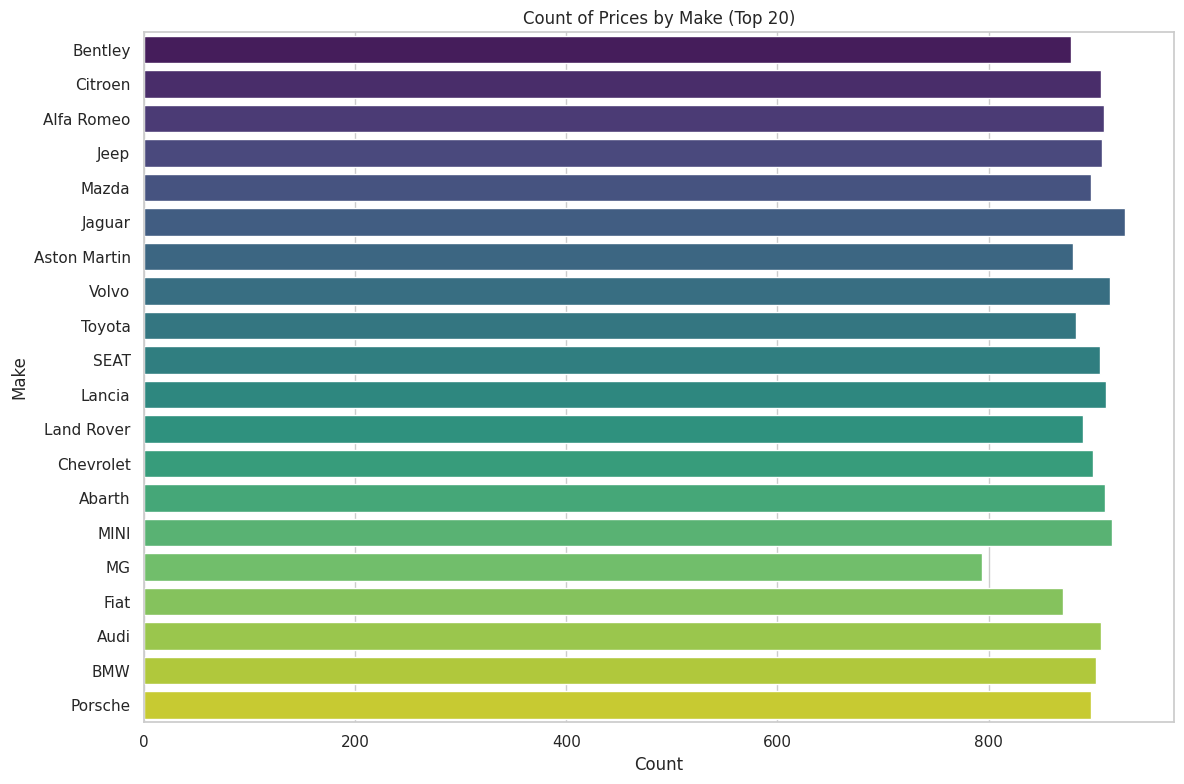

In [17]:
plt.figure(figsize=(12, 8))
sns.countplot(y='Make', data=df_used_cars, order=df['Make'].value_counts().index[:20], palette='viridis')
plt.title('Count of Prices by Make (Top 20)')
plt.xlabel('Count')
plt.ylabel('Make')
plt.tight_layout()
plt.show()

In [18]:
df_used_cars['Price'].mean()

np.float64(52915.25304255704)

/tmp/ipykernel_33365/1843581996.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_price_by_make.values, y=avg_price_by_make.index, palette='viridis')


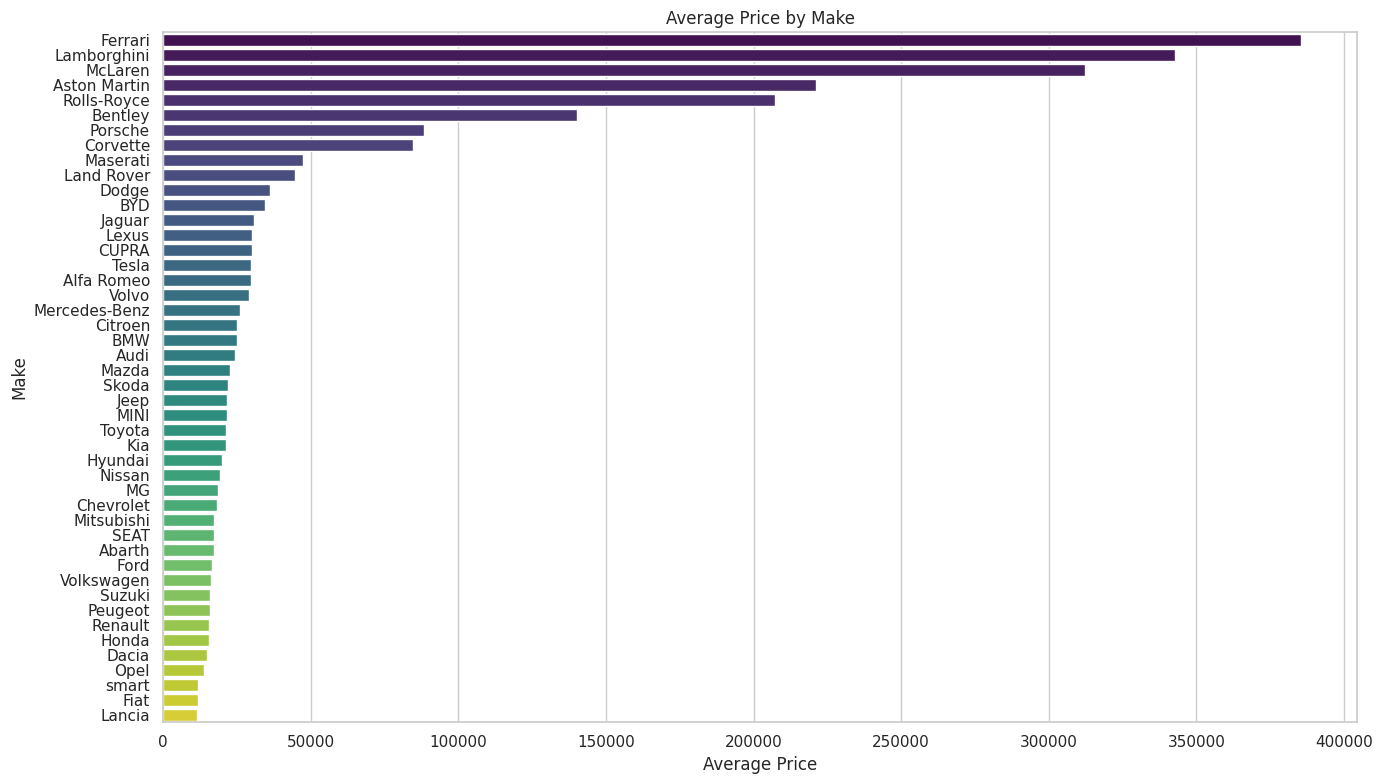

In [19]:
avg_price_by_make = df_used_cars.groupby('Make')['Price'].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 8))
sns.barplot(x=avg_price_by_make.values, y=avg_price_by_make.index, palette='viridis')
plt.title('Average Price by Make')
plt.xlabel('Average Price')
plt.ylabel('Make')
plt.tight_layout()
plt.show()

In [20]:
bins = [0, 15000, 30000, np.inf]
labels = [1, 2, 3]

df_used_cars['level'] = pd.cut(df_used_cars['Price'], bins=bins, labels=labels, right=True, include_lowest=True)

print("Distribución de niveles de precio:")
print(df_used_cars['level'].value_counts().sort_index())
print("\nPrimeras filas con la nueva columna 'level':")
print(df_used_cars[['Price', 'level']].head())

Distribución de niveles de precio:
level
1    12227
2    14635
3    11839
Name: count, dtype: int64

Primeras filas con la nueva columna 'level':
   Price level
0  16900     2
1  12500     1
2  17990     2
3   9300     1
4  14990     1


/tmp/ipykernel_33365/4170405803.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_used_cars['level'] = pd.cut(df_used_cars['Price'], bins=bins, labels=labels, right=True, include_lowest=True)


In [21]:
df_used_cars

,Make,Model,Body,Mileage_km,Price,Year,Country,Condition,Fuel_Type,Fuel_Consumption_l,...,Seats,Doors,Color,Upholstery,Full_Service_History,Non_Smoker_Vehicle,Previous_Owners,Seller,Image_url,level
0,Abarth,595,Compact,98000,16900,2020.0,IT,Used,Gasoline,6.7,...,4.0,3.0,White,Full leather,False,False,NaN,Dealer,https://prod.pictures.autoscout24.net/listing-...,2
1,Abarth,595,Sedan,91500,12500,2017.0,IT,Used,Gasoline,6.0,...,4.0,3.0,Grey,Full leather,False,True,4.0,Dealer,https://prod.pictures.autoscout24.net/listing-...,1
2,Abarth,595,Compact,40000,17990,2015.0,IT,Used,Gasoline,6.5,...,4.0,3.0,Bronze,Full leather,True,True,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...,2
3,Abarth,500,Compact,133000,9300,2008.0,IT,Used,Gasoline,6.5,...,4.0,3.0,Black,Cloth,True,True,2.0,Dealer,https://prod.pictures.autoscout24.net/listing-...,1
4,Abarth,595,Compact,61019,14990,2021.0,BE,Used,Gasoline,NaN,...,4.0,3.0,Yellow,Part leather,True,True,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40489,Volvo,V60 Cross Country,Station wagon,73627,32990,2023.0,DE,Used,Diesel,NaN,...,5.0,5.0,Grey,Part leather,True,True,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...,3
40490,Volvo,XC60,Off-Road/Pick-up,93671,26990,2020.0,IT,Used,Electric/Diesel,NaN,...,5.0,5.0,Grey,Cloth,False,False,NaN,Dealer,https://prod.pictures.autoscout24.net/listing-...,2
40491,Volvo,V90,Station wagon,60200,32490,2020.0,DE,Used,Gasoline,NaN,...,5.0,5.0,Black,Full leather,True,True,2.0,Dealer,https://prod.pictures.autoscout24.net/listing-...,3
40492,Volvo,XC40,Off-Road/Pick-up,49088,29450,2022.0,NL,Used,Electric/Gasoline,NaN,...,5.0,5.0,Black,Cloth,True,False,NaN,Dealer,https://prod.pictures.autoscout24.net/listing-...,2


In [23]:
used_cars_low = df_used_cars[df_used_cars['level'] == 1]
print("DataFrame 'used_cars_low' (primeras 5 filas):")
used_cars_low

DataFrame 'used_cars_low' (primeras 5 filas):


,Make,Model,Body,Mileage_km,Price,Year,Country,Condition,Fuel_Type,Fuel_Consumption_l,...,Seats,Doors,Color,Upholstery,Full_Service_History,Non_Smoker_Vehicle,Previous_Owners,Seller,Image_url,level
1,Abarth,595,Sedan,91500,12500,2017.0,IT,Used,Gasoline,6.0,...,4.0,3.0,Grey,Full leather,False,True,4.0,Dealer,https://prod.pictures.autoscout24.net/listing-...,1
3,Abarth,500,Compact,133000,9300,2008.0,IT,Used,Gasoline,6.5,...,4.0,3.0,Black,Cloth,True,True,2.0,Dealer,https://prod.pictures.autoscout24.net/listing-...,1
4,Abarth,595,Compact,61019,14990,2021.0,BE,Used,Gasoline,NaN,...,4.0,3.0,Yellow,Part leather,True,True,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...,1
6,Abarth,595,Compact,66678,14900,2019.0,IT,Used,Gasoline,6.6,...,4.0,3.0,Grey,Cloth,False,False,NaN,Dealer,https://prod.pictures.autoscout24.net/listing-...,1
13,Abarth,500,Sedan,139000,8799,2013.0,DE,Used,Gasoline,NaN,...,4.0,2.0,Black,Other,True,True,NaN,Dealer,https://prod.pictures.autoscout24.net/listing-...,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40447,Volvo,V40,Sedan,105329,13450,2017.0,DE,Used,Gasoline,NaN,...,5.0,5.0,White,Cloth,True,True,2.0,Dealer,https://prod.pictures.autoscout24.net/listing-...,1
40460,Volvo,V60,Station wagon,141565,13450,2015.0,NL,Used,Gasoline,NaN,...,5.0,5.0,Blue,Part leather,True,False,NaN,Dealer,https://prod.pictures.autoscout24.net/listing-...,1
40465,Volvo,V40,Sedan,140000,13900,2019.0,IT,Used,Diesel,4.5,...,5.0,5.0,Black,Full leather,False,False,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...,1
40468,Volvo,XC60,Off-Road/Pick-up,259176,9900,2011.0,ES,Used,Diesel,NaN,...,5.0,6.0,Black,NaN,False,False,NaN,Dealer,https://prod.pictures.autoscout24.net/listing-...,1


In [24]:
used_cars_low['Price'].mean()

np.float64(9282.579291731414)

In [26]:
used_cars_low['Make'].value_counts()

,count
Make,
Lancia,805
smart,734
Fiat,677
Chevrolet,666
Opel,545
Citroen,534
Honda,515
Dacia,462
Renault,459


In [28]:
used_cars_low[used_cars_low['Make']=='Lamborghini']

,Make,Model,Body,Mileage_km,Price,Year,Country,Condition,Fuel_Type,Fuel_Consumption_l,...,Seats,Doors,Color,Upholstery,Full_Service_History,Non_Smoker_Vehicle,Previous_Owners,Seller,Image_url,level
19119,Lamborghini,NaN,Coupe,1,15000,1971.0,NaN,Used,Gasoline,NaN,...,4.0,2.0,Red,NaN,False,False,NaN,PrivateSeller,https://prod.pictures.autoscout24.net/listing-...,1


In [29]:
used_cars_low.columns

Index(['Make', 'Model', 'Body', 'Mileage_km', 'Price', 'Year', 'Country',
       'Condition', 'Fuel_Type', 'Fuel_Consumption_l', 'Drivetrain', 'Gearbox',
       'Gears', 'Power_hp', 'Engine_Size_cc', 'Cylinders', 'Seats', 'Doors',
       'Color', 'Upholstery', 'Full_Service_History', 'Non_Smoker_Vehicle',
       'Previous_Owners', 'Seller', 'Image_url', 'level'],
      dtype='object')

In [55]:
df_used_cars_low = used_cars_low[['Mileage_km', 'Price', 'Year',
       'Fuel_Type', 'Drivetrain', 'Gearbox',
       'Gears', 'Power_hp', 'Engine_Size_cc', 'Cylinders', 'Seats', 'Doors',
       'Color', 'Upholstery', 'Full_Service_History', 'Non_Smoker_Vehicle',
       'Previous_Owners']]
df_used_cars_low

,Mileage_km,Price,Year,Fuel_Type,Drivetrain,Gearbox,Gears,Power_hp,Engine_Size_cc,Cylinders,Seats,Doors,Color,Upholstery,Full_Service_History,Non_Smoker_Vehicle,Previous_Owners
1,91500,12500,2017.0,Gasoline,Front Wheel Drive,Manual,5.0,165,1368.0,4.0,4.0,3.0,Grey,Full leather,False,True,4.0
3,133000,9300,2008.0,Gasoline,Front Wheel Drive,Manual,5.0,160,1368.0,4.0,4.0,3.0,Black,Cloth,True,True,2.0
4,61019,14990,2021.0,Gasoline,Front Wheel Drive,Manual,6.0,145,1368.0,4.0,4.0,3.0,Yellow,Part leather,True,True,1.0
6,66678,14900,2019.0,Gasoline,Front Wheel Drive,Manual,5.0,145,1368.0,4.0,4.0,3.0,Grey,Cloth,False,False,NaN
13,139000,8799,2013.0,Gasoline,Front Wheel Drive,Manual,NaN,135,1368.0,4.0,4.0,2.0,Black,Other,True,True,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40447,105329,13450,2017.0,Gasoline,Front Wheel Drive,Manual,6.0,122,1969.0,4.0,5.0,5.0,White,Cloth,True,True,2.0
40460,141565,13450,2015.0,Gasoline,Front Wheel Drive,Automatic,NaN,150,1596.0,4.0,5.0,5.0,Blue,Part leather,True,False,NaN
40465,140000,13900,2019.0,Diesel,Front Wheel Drive,Automatic,6.0,120,1969.0,4.0,5.0,5.0,Black,Full leather,False,False,1.0
40468,259176,9900,2011.0,Diesel,NaN,Manual,NaN,162,NaN,NaN,5.0,6.0,Black,NaN,False,False,NaN


# DATOS FALTANTES

In [56]:
df_used_cars_low.missing.number_missing()

np.int64(20484)

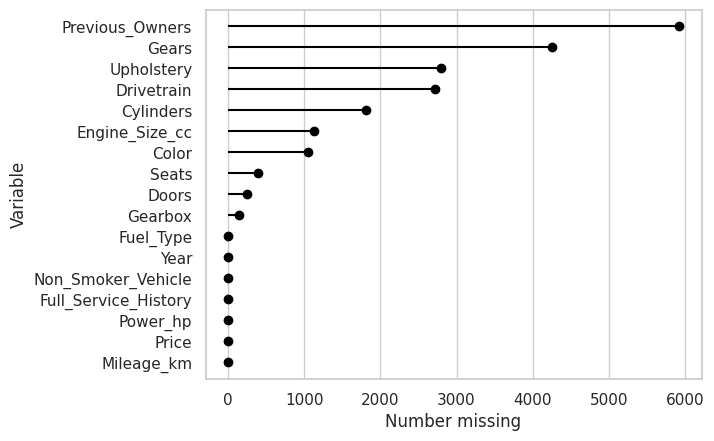

In [57]:
df_used_cars_low.missing.missing_variable_plot()

In [58]:
df_used_cars_low.dtypes

,0
Mileage_km,int64
Price,int64
Year,float64
Fuel_Type,object
Drivetrain,object
Gearbox,object
Gears,float64
Power_hp,int64
Engine_Size_cc,float64
Cylinders,float64


In [59]:
import missingno

<Axes: >

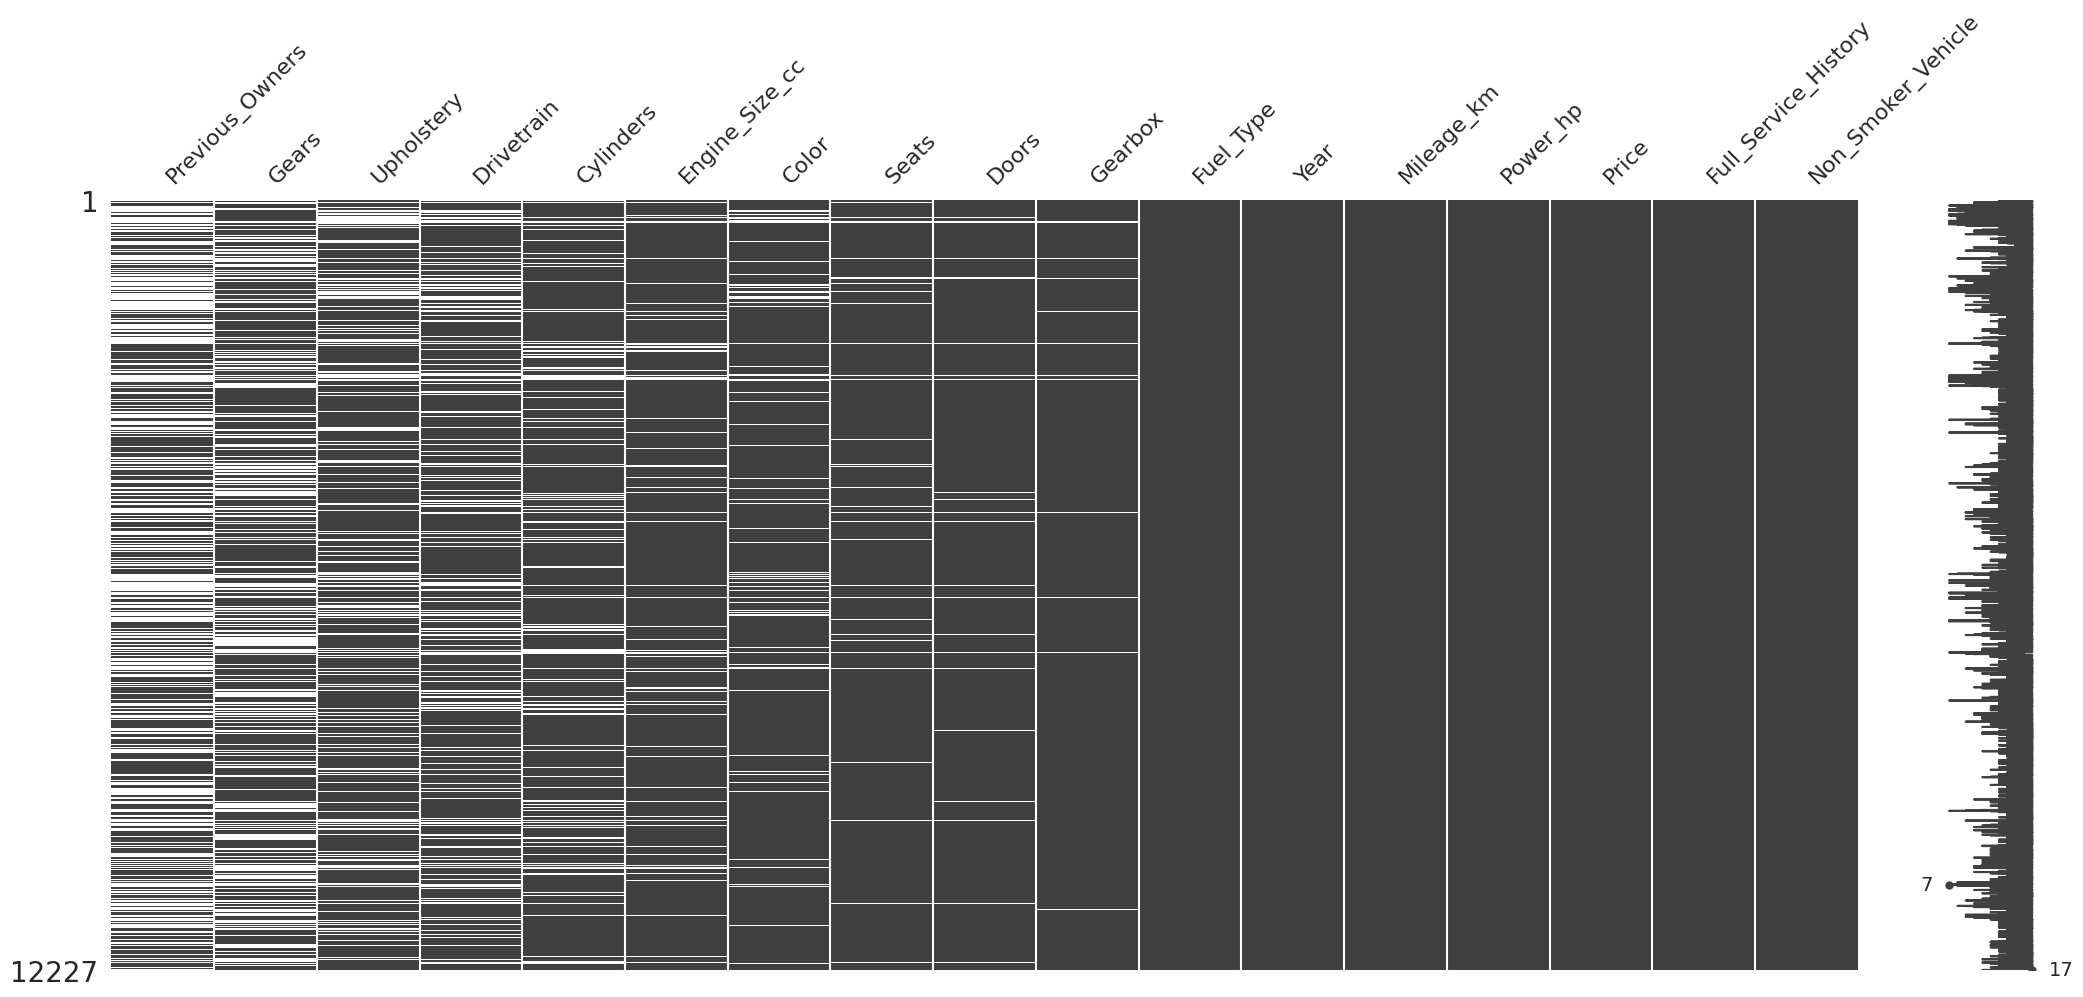

In [60]:
(
    df_used_cars_low
    .missing.sort_variables_by_missingness()
    .pipe(missingno.matrix)
)

# IMPUTACIÓN DE VARIABLES NÚMERICAS

In [61]:
numeric_nans = ['Previous_Owners','Gears','Cylinders','Engine_Size_cc','Seats','Doors','Year']

In [62]:
df_cleaned = df_used_cars_low.copy()

In [63]:
for variable in numeric_nans:
  df_cleaned[variable] = df_cleaned[variable].fillna(float(df_cleaned[variable].mean()))

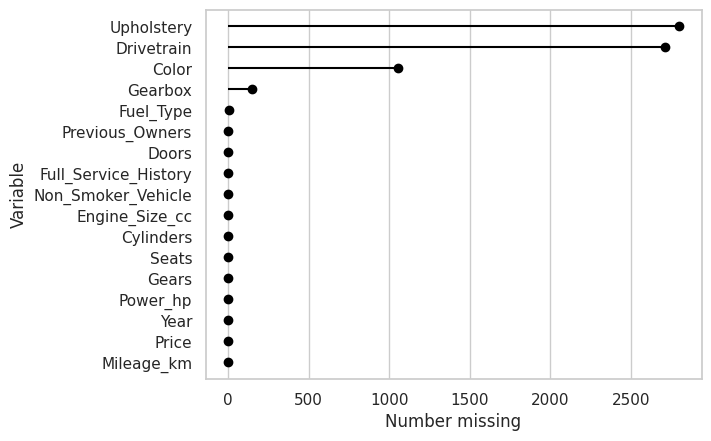

In [64]:
df_cleaned.missing.missing_variable_plot()

# IMPUTACIÓN DE VARIABLES CATEGORICAS

In [65]:
object_nans = ['Upholstery','Drivetrain','Color','Gearbox','Fuel_Type']

In [66]:
for variable in object_nans:
  df_cleaned[variable] = df_cleaned[variable].ffill()
  df_cleaned[variable] = df_cleaned[variable].bfill()

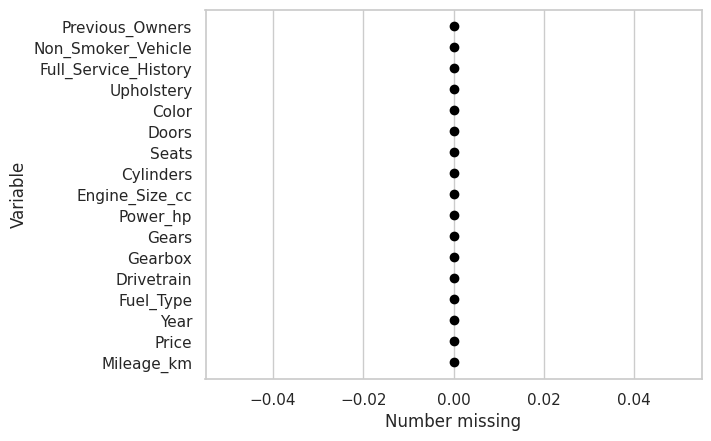

In [67]:
df_cleaned.missing.missing_variable_plot()

# DATOS ATIPICOS

In [68]:
df_cleaned.describe()

,Mileage_km,Price,Year,Gears,Power_hp,Engine_Size_cc,Cylinders,Seats,Doors,Previous_Owners
count,1.222700e+04,12227.000000,12227.000000,12227.000000,12227.000000,12227.000000,12227.000000,12227.000000,12227.000000,12227.000000
mean,1.293701e+05,9282.579292,2014.219614,5.486510,118.413675,1539.942316,3.825761,4.736731,4.398548,1.663126
std,3.562199e+05,4050.505878,7.091335,1.167993,51.549463,653.266100,0.817461,2.427501,0.941176,1.084939
min,0.000000e+00,1.000000,1951.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000
25%,6.641400e+04,5990.000000,2011.000000,5.000000,82.000000,1197.000000,3.000000,4.736731,4.000000,1.000000
50%,1.118450e+05,9900.000000,2015.000000,5.486510,110.000000,1461.000000,4.000000,5.000000,5.000000,1.663126
75%,1.663980e+05,12900.000000,2019.000000,6.000000,140.000000,1598.000000,4.000000,5.000000,5.000000,1.663126
max,1.677722e+07,15000.000000,2025.000000,69.000000,700.000000,7997.000000,12.000000,255.000000,6.000000,94.000000


In [190]:
variable = 'Previous_Owners'
data = df_cleaned[variable]

In [197]:
mean_val = data.mean()
median_val = data.median()
mode_val = data.mode()[0]

print(f"📊 Medidas de tendencia central de {variable}")
print(f"Media (μ): {mean_val:.2f}")
print(f"Mediana: {median_val:.2f}")
print(f"Moda: {mode_val:.2f}")

📊 Medidas de tendencia central de Previous_Owners
Media (μ): 1.48
Mediana: 1.66
Moda: 1.66


In [198]:
variance_val = data.var()
std_val = data.std()
range_val = data.max() - data.min()
q1 = data.quantile(0.25)
q3 = data.quantile(0.75)
iqr = q3 - q1
print(f"\n📈 Medidas de dispersión de {variable}")
print(f"Varianza (σ²): {variance_val:.2f}")
print(f"Desviación estándar (σ): {std_val:.2f}")
print(f"Rango: {range_val:.2f}")
print(f"Rango intercuartílico (IQR): {iqr:.2f}")


📈 Medidas de dispersión de Previous_Owners
Varianza (σ²): 0.14
Desviación estándar (σ): 0.37
Rango: 1.00
Rango intercuartílico (IQR): 0.66


In [199]:
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

outliers = data[(data < limite_inferior) | (data > limite_superior)]

print(f"\n⚠️ Detección de Outliers (Regla del IQR) para {variable}")
print(f"Límite inferior: {limite_inferior:.2f}")
print(f"Límite superior: {limite_superior:.2f}")
print(f"Número de outliers detectados: {len(outliers)}")


⚠️ Detección de Outliers (Regla del IQR) para Previous_Owners
Límite inferior: 0.01
Límite superior: 2.66
Número de outliers detectados: 0


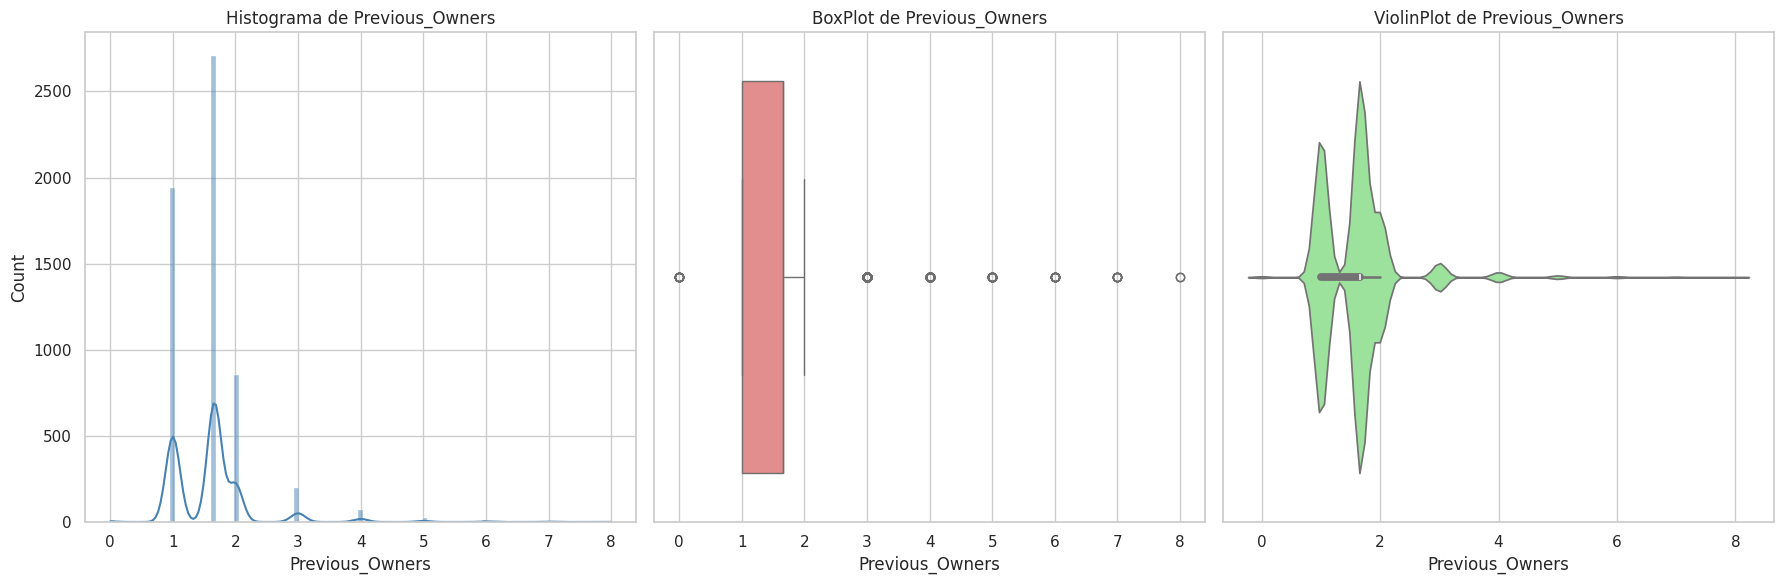

In [194]:
fig,axes = plt.subplots(1,3,figsize=(18,6))

#histograma
sns.histplot(data,kde=True,color='steelblue',ax=axes[0])
axes[0].set_title(f'Histograma de {variable}')

#boxplot
sns.boxplot(x=data,color='lightcoral',ax=axes[1])
axes[1].set_title(f'BoxPlot de {variable}')

#violinplot
sns.violinplot(x=data,color='lightgreen',ax=axes[2])
axes[2].set_title(f'ViolinPlot de {variable}')

plt.tight_layout()
plt.show()

# ELIMINAR OUTLIERS

In [195]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

In [196]:
df_cleaned = remove_outliers(df_cleaned,variable)
data = df_cleaned[variable]

In [200]:
df_cleaned

,Mileage_km,Price,Year,Fuel_Type,Drivetrain,Gearbox,Gears,Power_hp,Engine_Size_cc,Cylinders,Seats,Doors,Color,Upholstery,Full_Service_History,Non_Smoker_Vehicle,Previous_Owners
923,104779,7999,2011.0,Gasoline,Front Wheel Drive,Automatic,6.00000,170,1368.0,4.0,5.0,5.0,Grey,Full leather,False,False,1.663126
924,142795,8900,2015.0,Diesel,Front Wheel Drive,Manual,6.00000,105,1598.0,4.0,5.0,5.0,Grey,Full leather,False,False,1.663126
926,148228,7890,2016.0,Gasoline,Front Wheel Drive,Manual,6.00000,120,1368.0,4.0,5.0,5.0,Grey,Cloth,True,True,1.000000
930,209000,5490,2013.0,Diesel,Front Wheel Drive,Automatic,6.00000,170,1956.0,4.0,5.0,5.0,Grey,Full leather,True,False,1.000000
936,67761,14900,2020.0,Diesel,Front Wheel Drive,Manual,6.00000,120,1598.0,4.0,5.0,5.0,Silver,Cloth,False,False,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40392,159989,13948,2016.0,Diesel,Front Wheel Drive,Manual,6.00000,150,1969.0,4.0,5.0,5.0,Black,Full leather,False,False,1.663126
40433,90452,10950,2013.0,Gasoline,Front Wheel Drive,Manual,6.00000,120,1596.0,4.0,5.0,5.0,White,Full leather,True,True,1.663126
40447,105329,13450,2017.0,Gasoline,Front Wheel Drive,Manual,6.00000,122,1969.0,4.0,5.0,5.0,White,Cloth,True,True,2.000000
40460,141565,13450,2015.0,Gasoline,Front Wheel Drive,Automatic,5.48651,150,1596.0,4.0,5.0,5.0,Blue,Part leather,True,False,1.663126


In [201]:
df_cleaned.to_csv('used_cars_low_cleaned.csv',index=None)